# CART Analysis — Human ITL

End-to-end workflow for segmenting, curating, and quantifying CART / B-cell / vasculature / tumour images from LIF stacks.

**Pipeline**
1. **Configure** — set LIF folder + output folder once (next cell).
2. **Imports & functions** — run once per session.
3. **Step 1 — Segment** all LIF images → combined TIFs (raw + labels + metadata).
4. **Step 2 — Review** labels in napari (edit `chip` / `tumour` as needed).
5. **Step 3 — Analyse** curated labels → counts, distances, colocalisation CSVs.
6. **Plots** — CART scatter / bar / enrichment figures.

> Tip: after Step 1, copy the best segmentations into a `best_labels/` folder and point `CURATED_DIR` at it for Step 3.


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Imports and GPU check
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import json
import pathlib
import warnings
import contextlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import tifffile
import liffile
import napari
from napari.utils.colormaps import DirectLabelColormap
from scipy.ndimage import distance_transform_edt
from scipy import stats as scipy_stats
from skimage.filters import gaussian, median as median_filter, threshold_li, threshold_mean, threshold_triangle, threshold_yen
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import closing, disk, square, erosion, remove_small_holes
from skimage.segmentation import watershed, expand_labels
from skimage.feature import peak_local_max
import joblib
from joblib import Parallel, delayed
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── GPU availability ──────────────────────────────────────────────────────────
GPU_AVAILABLE = False
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
except ImportError:
    pass
print(f"GPU available: {GPU_AVAILABLE}")


@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib so it updates a tqdm progress bar."""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

GPU available: True


## Configuration

Set all paths and parameters **here**. Every downstream cell reads from these variables.


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIG — edit these paths then run the rest of the notebook
# ══════════════════════════════════════════════════════════════════════════════
LIF_DIR      = pathlib.Path(r"Z:\Marina\Stellaris\2026.03.10_CART\For analysis")
LABEL_DIR    = LIF_DIR / "labels"          # Step 1 writes combined TIFs here
CURATED_DIR  = LIF_DIR / "best_labels"     # Step 3 reads curated TIFs from here
OUTPUT_DIR   = CURATED_DIR / "output_figures"

NUM_WORKERS  = 4  # parallel workers for segmentation + analysis

LABEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"LIF folder:     {LIF_DIR}")
print(f"Labels folder:  {LABEL_DIR}")
print(f"Curated folder: {CURATED_DIR}")
print(f"Output folder:  {OUTPUT_DIR}")

LIF folder:     Z:\Marina\Stellaris\2026.03.10_CART\For analysis
Labels folder:  Z:\Marina\Stellaris\2026.03.10_CART\For analysis\labels
Curated folder: Z:\Marina\Stellaris\2026.03.10_CART\For analysis\best_labels
Output folder:  Z:\Marina\Stellaris\2026.03.10_CART\For analysis\best_labels\output_figures


## Functions & constants

Run once per session. Contains segmentation, combined-TIF I/O, the napari review GUI, and analysis helpers.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Functions
# ══════════════════════════════════════════════════════════════════════════════
# Combined TIF layout: (N_raw + 5, Y, X) float32
#   First N_raw channels: raw projection (one per microscope channel)
#   Last 5 channels: chip, vasculature, b_cells, cart_cells, tumour
#
# Channel layout depends on the raw channel count of each image — see
# `channels_for(n_channels)` below. Returns a dict mapping role names
# ('b_cell', 'brightfield', 'cart', 'vasculature') → raw-channel index.
LABEL_NAMES = ["chip", "vasculature", "b_cells", "cart_cells", "tumour"]
EDITABLE_LABELS = ["chip", "tumour"]

LABEL_COLORMAPS = {
    "chip":        DirectLabelColormap(color_dict={0: "transparent", 1: "cyan"}),
    "vasculature": DirectLabelColormap(color_dict={0: "transparent", 1: "magenta"}),
    "b_cells":     DirectLabelColormap(color_dict={0: "transparent", 1: "green"}),
    "cart_cells":  DirectLabelColormap(color_dict={0: "transparent", 1: "red"}),
    "tumour":      DirectLabelColormap(color_dict={0: "transparent", 1: "yellow"}),
}

OVERLAY_COLORS = {
    "Chip":        [0, 1, 1, 0.35],
    "Tumour":      [1, 1, 0, 0.45],
    "Vasculature": [1, 0, 1, 0.40],
    "CART cells":  [1, 0, 0, 0.45],
    "B cells":     [0, 1, 0, 0.45],
}


def channels_for(n_channels):
    """Map raw channel count → role-to-index dict for this dataset."""
    if n_channels == 5:
        return {"b_cell": 0, "brightfield": 1, "vasculature": 3, "cart": 4}
    if n_channels == 4:
        return {"b_cell": 0, "vasculature": 1, "brightfield": 2, "cart": 3}
    raise ValueError(f"Unsupported channel count: {n_channels}")


def raw_channel_names(n_raw, channels):
    """Return a list of length n_raw naming each raw channel from `channels`."""
    names = [f"Ch{i}" for i in range(n_raw)]
    for role, raw_index in channels.items():
        resolved = raw_index % n_raw
        if names[resolved].startswith("Ch"):
            names[resolved] = role
        else:
            names[resolved] = f"{names[resolved]} / {role}"
    return names


def count_cells(region_mask, centroid_rows, centroid_cols):
    """Count how many cell centroids fall inside a binary region mask."""
    if len(centroid_rows) == 0:
        return 0
    return int(region_mask[centroid_rows, centroid_cols].sum())


def add_experiment_info(dataframe):
    """Extract patient, day, flow, fixation, and experiment from image/lif_file columns."""
    combined_name = dataframe["image"].astype(str).str.lower() + dataframe["lif_file"].astype(str).str.lower()
    image_name = dataframe["image"].astype(str).str.lower()

    dataframe["patient"] = np.where(combined_name.str.contains("fl32"), "fl32",
                           np.where(combined_name.str.contains("fl12"), "fl12", "unknown"))

    dataframe["day"] = np.where(image_name.str.contains("day10"), "10",
                       np.where(image_name.str.contains("day8"), "8",
                       np.where(image_name.str.contains("day9"), "9",
                       np.where(image_name.str.contains("day7"), "7",
                       np.where(image_name.str.contains("day6"), "6", "unknown")))))

    dataframe["flow"] = np.where(combined_name.str.contains("3mm"), "3mm",
                        np.where(combined_name.str.contains("7mm"), "7mm", "unknown"))

    dataframe["fixation"] = np.where(combined_name.str.contains("fix"), "fixed", "live")

    dataframe["experiment"] = np.where(
        dataframe["image"].astype(str).str.contains("ARi", case=False, na=False), "ARi", "UTD")

    return dataframe


# ── Segmentation functions ────────────────────────────────────────────────────

def segment_chip(max_projection, brightfield_channel):
    """Segment the chip region from the brightfield channel.

    Returns (chip_mask, smoothed_brightfield).
    """
    brightfield = max_projection[brightfield_channel]
    clipped = np.clip(brightfield, np.percentile(brightfield, 25), np.percentile(brightfield, 90))
    smoothed = gaussian(clipped, sigma=7)
    bright_pixels = smoothed > threshold_li(smoothed)
    labelled_bright = label(bright_pixels)
    image_height = smoothed.shape[0]

    # Identify left and right off-chip regions
    left_labels = set(labelled_bright[:, 0]) - {0}
    left_region = np.isin(labelled_bright, list(left_labels))
    left_region = closing(left_region, disk(10))
    left_region = remove_small_holes(left_region.astype(bool), area_threshold=500000)

    right_labels = set(labelled_bright[:, -1]) - {0}
    right_region = np.isin(labelled_bright, list(right_labels))
    right_region = closing(right_region, disk(10))
    right_region = remove_small_holes(right_region.astype(bool), area_threshold=500000)

    # Fallback to mean threshold if first pass grabs too much
    if left_region[:, 0].sum() > image_height / 2:
        bright_mean = smoothed > threshold_mean(smoothed)
        labelled_mean = label(bright_mean)
        left_mean_labels = set(labelled_mean[:, 0]) - {0}
        left_region = np.isin(labelled_mean, list(left_mean_labels))
        left_region = closing(left_region, disk(10))
        left_region = remove_small_holes(left_region.astype(bool), area_threshold=500000)

    if right_region[:, -1].sum() > image_height / 2:
        bright_mean = smoothed > threshold_mean(smoothed)
        labelled_mean = label(bright_mean)
        right_mean_labels = set(labelled_mean[:, -1]) - {0}
        right_region = np.isin(labelled_mean, list(right_mean_labels))
        right_region = closing(right_region, disk(10))
        right_region = remove_small_holes(right_region.astype(bool), area_threshold=500000)

    chip_mask = (~left_region & ~right_region).astype(bool)
    return chip_mask, smoothed


def segment_tumour(smoothed_brightfield, chip_mask):
    """Segment the tumour from the smoothed brightfield, restricted to chip."""
    image_centre = np.array([smoothed_brightfield.shape[0] / 2, smoothed_brightfield.shape[1] / 2])

    def pick_best_tumour(labelled_image):
        properties = pd.DataFrame(regionprops_table(
            labelled_image, properties=("label", "area", "perimeter", "centroid")))
        properties = properties[properties["area"] >= 0.01 * labelled_image.size] if not properties.empty else properties
        if properties.empty:
            return None
        circularity = (4 * np.pi * properties["area"]) / (properties["perimeter"] ** 2 + 1e-9)
        distance_to_centre = np.hypot(
            properties["centroid-0"] - image_centre[0],
            properties["centroid-1"] - image_centre[1])
        properties["score"] = properties["area"] * circularity / (1 + distance_to_centre)
        return int(properties.loc[properties["score"].idxmax(), "label"])

    tumour_raw = (smoothed_brightfield < threshold_triangle(smoothed_brightfield)) & chip_mask
    labelled_tumour = label(tumour_raw)
    chosen_label = pick_best_tumour(labelled_tumour)
    tumour_mask = (labelled_tumour == chosen_label) if chosen_label is not None else tumour_raw

    for erosion_radius, expansion_distance in [(10, 10), (50, 60)]:
        tumour_properties = regionprops(label(tumour_mask))
        if not tumour_properties or tumour_properties[0].solidity >= 0.9:
            break
        eroded = erosion(tumour_mask, disk(erosion_radius))
        eroded_labelled = label(eroded)
        chosen_eroded = pick_best_tumour(eroded_labelled)
        if chosen_eroded is not None:
            tumour_mask = (expand_labels(eroded_labelled, distance=expansion_distance) == chosen_eroded)

    tumour_mask = tumour_mask.astype(bool)
    tumour_mask = remove_small_holes(tumour_mask, area_threshold=500000)
    tumour_pixels = smoothed_brightfield[tumour_mask]
    if tumour_pixels.size > 0:
        smoothed_for_watershed = gaussian(smoothed_brightfield, sigma=10)
        euclidean_distance = distance_transform_edt(tumour_mask)
        peak_coords = peak_local_max(euclidean_distance, min_distance=60,
                                     labels=tumour_mask.astype(int), num_peaks=2)
        if len(peak_coords) >= 2:
            markers = np.zeros_like(tumour_mask, dtype=int)
            for marker_index, (row, col) in enumerate(peak_coords, start=1):
                markers[row, col] = marker_index
            watershed_labels = watershed(smoothed_for_watershed, markers, mask=tumour_mask)
            watershed_medians = {}
            for watershed_value in np.unique(watershed_labels[watershed_labels > 0]):
                watershed_medians[watershed_value] = float(
                    np.median(smoothed_brightfield[watershed_labels == watershed_value]))
            darkest_label = min(watershed_medians, key=watershed_medians.get)
            tumour_mask = (watershed_labels == darkest_label)

    return tumour_mask.astype(bool)


# ── Combined TIF I/O ─────────────────────────────────────────────────────────

def segment_and_save(lif_image, output_directory, lif_path=None):
    """Project a LIF image to 2D, auto-segment, save raw + labels in a (N+5,Y,X) TIF.

    The output filename is "{lif_stem}__{image_name}.tif" so the source LIF
    is identifiable from the label file alone. Channel roles are derived per
    image from its raw channel count via `channels_for`.
    """
    output_directory = pathlib.Path(output_directory)
    output_directory.mkdir(exist_ok=True, parents=True)

    lif_stem = lif_path.stem if lif_path else ""
    raw_name = f"{lif_stem}__{lif_image.name}" if lif_stem else lif_image.name
    safe_name = raw_name.replace("/", "_").replace("\\", "_")

    combined_name_lower = (lif_image.name + lif_stem).lower()
    metadata = {
        "image_name": lif_image.name,
        "lif_file": lif_stem,
        "patient": "fl32" if "fl32" in combined_name_lower else "fl12" if "fl12" in combined_name_lower else "unknown",
        "day": "6" if "day6" in combined_name_lower else "7" if "day7" in combined_name_lower else "unknown",
    }

    max_projection = np.max(lif_image.asarray(), axis=lif_image.dims.index('Z'))
    n_raw = int(max_projection.shape[0])
    channels = channels_for(n_raw)

    try:
        x_coords = lif_image.coords["X"]
        um_per_px = abs(float(x_coords[1] - x_coords[0])) * 1e6
        if um_per_px <= 0:
            raise ValueError
    except Exception:
        um_per_px = 1.0
        warnings.warn(f"Could not read pixel size for {lif_image.name}, using 1 µm/px")
    metadata["um_per_px"] = um_per_px
    metadata["n_raw_channels"] = n_raw

    # Cell segmentation (binary)
    bcell_raw = max_projection[channels["b_cell"]]
    cart_raw  = max_projection[channels["cart"]]
    bcell_mask = (bcell_raw > threshold_yen(bcell_raw)).astype(np.uint8)
    cart_mask  = (cart_raw  > threshold_yen(cart_raw)).astype(np.uint8)

    # Vasculature
    vasculature_raw = max_projection[channels["vasculature"]]
    vasculature_median = median_filter(vasculature_raw, footprint=square(7))
    vasculature_smoothed = gaussian(vasculature_median, sigma=3)
    vasculature_mask = vasculature_smoothed > threshold_triangle(vasculature_smoothed)
    labelled_vasculature = label(vasculature_mask)
    vasculature_properties = pd.DataFrame(regionprops_table(labelled_vasculature, properties=("area", "solidity")))
    if float(vasculature_properties.loc[vasculature_properties["area"].idxmax(), "solidity"]) > 0.9:
        vasculature_mask = vasculature_smoothed > threshold_li(vasculature_smoothed)
    vasculature_mask = vasculature_mask.astype(np.uint8)

    # Chip and tumour
    chip_mask, smoothed_brightfield = segment_chip(max_projection, channels["brightfield"])
    tumour_mask = segment_tumour(smoothed_brightfield, chip_mask).astype(np.uint8)

    # Stack labels: (5, Y, X) — chip, vasculature, b_cells, cart_cells, tumour
    labels_stack = np.stack([chip_mask.astype(np.uint8), vasculature_mask,
                             bcell_mask, cart_mask, tumour_mask], axis=0)
    combined = np.concatenate([max_projection.astype(np.float32),
                               labels_stack.astype(np.float32)], axis=0)

    tifffile.imwrite(str(output_directory / f"{safe_name}.tif"),
                     combined, imagej=True, metadata={'Info': json.dumps(metadata)})

    print(f"  Saved: {safe_name}")
    return safe_name


def load_combined_tif(filepath):
    """Load a combined TIF and return (raw, labels, metadata_json_string)."""
    n_label_channels = len(LABEL_NAMES)
    with tifffile.TiffFile(str(filepath)) as tif:
        data = tif.asarray()
        imagej_metadata = tif.imagej_metadata or {}
        metadata_json_string = imagej_metadata.get('Info', None)
    raw = data[:-n_label_channels]
    labels = data[-n_label_channels:].astype(np.uint8)
    return raw, labels, metadata_json_string


def save_combined_tif(filepath, raw, labels, metadata_json_string=None):
    """Re-save a combined TIF from raw + labels arrays."""
    combined = np.concatenate([raw.astype(np.float32), labels.astype(np.float32)], axis=0)
    metadata = {'Info': metadata_json_string} if metadata_json_string else {}
    tifffile.imwrite(str(filepath), combined, imagej=True, metadata=metadata)



In [ ]:
############ NAPARI REVIEW
def review_in_napari(label_directory):
    """Load ONE combined TIF at a time into Napari for manual correction.

    Channel roles for each image are derived from its raw channel count via
    `channels_for`.
    """
    from magicgui import magicgui
    label_directory = pathlib.Path(label_directory)

    image_list = sorted(label_directory.glob("*.tif"))
    if not image_list:
        print("No images found in", label_directory)
        return None, None

    viewer = napari.Viewer()
    state = {"idx": 0, "label_layers": {}, "raw": None, "labels": None,
             "dirty": False, "meta_info": None}

    def save_current():
        if not state["label_layers"] or state["labels"] is None:
            return
        tif_path = image_list[state["idx"]]
        updated_labels = state["labels"].copy()
        for label_name, layer in state["label_layers"].items():
            label_index = LABEL_NAMES.index(label_name)
            updated_labels[label_index] = (layer.data > 0).astype(np.uint8)
        save_combined_tif(tif_path, state["raw"], updated_labels, state["meta_info"])
        state["labels"] = updated_labels
        state["dirty"] = False
        print(f"  Saved: {tif_path.name}")

    def load_image(index):
        if state["dirty"]:
            save_current()
        state["label_layers"] = {}
        viewer.layers.clear()

        tif_path = image_list[index]
        state["idx"] = index
        safe = tif_path.stem

        raw, labels, metadata_json_string = load_combined_tif(tif_path)
        state["raw"] = raw
        state["labels"] = labels.copy()
        state["meta_info"] = metadata_json_string

        n_raw = raw.shape[0]
        channels = channels_for(n_raw)
        channel_names = raw_channel_names(n_raw, channels)
        brightfield_index = channels["brightfield"] % n_raw
        for channel_index in range(n_raw):
            viewer.add_image(raw[channel_index], name=channel_names[channel_index],
                             visible=(channel_index == brightfield_index), blending="additive")

        for label_name in EDITABLE_LABELS:
            label_index = LABEL_NAMES.index(label_name)
            layer = viewer.add_labels(labels[label_index], name=label_name,
                                      colormap=LABEL_COLORMAPS.get(label_name))
            state["label_layers"][label_name] = layer

        viewer.title = f"[{index + 1}/{len(image_list)}] {safe}"
        state["dirty"] = True
        print(f"Loaded [{index + 1}/{len(image_list)}]: {safe}")

    def navigate_next():
        if state["idx"] < len(image_list) - 1:
            load_image(state["idx"] + 1)
        else:
            print("Already at last image.")

    def navigate_prev():
        if state["idx"] > 0:
            load_image(state["idx"] - 1)
        else:
            print("Already at first image.")

    def goto_image(index):
        if 0 <= index < len(image_list):
            load_image(index)
        else:
            print(f"Index {index} out of range (0–{len(image_list)-1})")

    def reset_label(label_name):
        if label_name not in EDITABLE_LABELS:
            print(f"Unknown label '{label_name}'. Choose from: {EDITABLE_LABELS}")
            return
        old_layer = state["label_layers"][label_name]
        shape = old_layer.data.shape
        viewer.layers.remove(old_layer)
        blank = np.zeros(shape, dtype=old_layer.data.dtype)
        new_layer = viewer.add_labels(blank, name=label_name,
                                      colormap=LABEL_COLORMAPS.get(label_name))
        state["label_layers"][label_name] = new_layer
        state["dirty"] = True
        print(f"  Reset '{label_name}' to blank. Paint with value 1 to redraw.")

    @viewer.bind_key("n")
    def key_next(viewer):
        navigate_next()

    @viewer.bind_key("b")
    def key_prev(viewer):
        navigate_prev()

    @viewer.bind_key("Control-s")
    def key_save(viewer):
        save_current()

    _reset_label = reset_label  # capture before magicgui shadows the name

    @magicgui(
        call_button="Reset Label",
        label_name={"choices": EDITABLE_LABELS, "label": "Label to reset"},
    )
    def reset_widget(label_name=EDITABLE_LABELS[0]):
        _reset_label(label_name)

    viewer.window.add_dock_widget(reset_widget, name="Reset Label", area="right")
    load_image(0)
    print(f"\n{len(image_list)} images found. Shortcuts: n=next, b=back, Ctrl+S=save")
    print("Labels auto-save when you navigate to the next/prev image.")

    class Controls:
        next = staticmethod(navigate_next)
        prev = staticmethod(navigate_prev)
        save = staticmethod(save_current)
        goto = staticmethod(goto_image)
        reset_label = staticmethod(_reset_label)
        n_images = len(image_list)

    return viewer, Controls()

In [ ]:

# ── Analysis functions ────────────────────────────────────────────────────────

def analyse_one_image(tif_path,
                      gauss_sigmas_um=(5, 10, 20, 50, 100),
                      proximity_radii_um=(5, 10, 20, 30, 40, 50, 100),
                      output_folder=None):
    """Analyse a single combined TIF: cell counts, distances, and colocalisation.

    Channel roles are derived from the raw channel count via `channels_for`.
    Returns (counts_dataframe, distances_dataframe, colocalisation_dataframe).
    """
    raw, labels_array, metadata_json_string = load_combined_tif(tif_path)
    metadata = json.loads(metadata_json_string) if metadata_json_string else {}
    um_per_px = metadata.get("um_per_px", 1.0)
    channels = channels_for(raw.shape[0])

    chip_mask = labels_array[0].astype(bool)
    vasculature_mask = labels_array[1].astype(bool)
    bcell_mask = labels_array[2].astype(bool)
    cart_mask = labels_array[3].astype(bool)
    tumour_mask = labels_array[4].astype(bool)

    not_chip = ~chip_mask
    labelled_not_chip = label(not_chip)
    left_mask = np.zeros_like(chip_mask)
    right_mask = np.zeros_like(chip_mask)
    for region_props in regionprops(labelled_not_chip):
        coords = region_props.coords
        if np.any(coords[:, 1] == 0):
            left_mask[labelled_not_chip == region_props.label] = True
        if np.any(coords[:, 1] == chip_mask.shape[1] - 1):
            right_mask[labelled_not_chip == region_props.label] = True

    region_masks = {
        "chip":                 chip_mask,
        "not_chip":             not_chip,
        "tumour":               chip_mask & tumour_mask,
        "chip_not_tumour":      chip_mask & ~tumour_mask,
        "chip_vasculature":     chip_mask & vasculature_mask,
        "chip_not_vasculature": chip_mask & ~vasculature_mask,
        "left":                 left_mask.astype(bool),
        "right":                right_mask.astype(bool),
    }

    tumour_distance_map = distance_transform_edt(~tumour_mask)
    image_name = metadata.get("image_name", tif_path.stem)
    base_metadata = {key: metadata.get(key, "unknown") for key in ("lif_file", "patient", "day")}

    count_records = []
    distance_records = []

    for cell_type_name, cell_mask in [("CART cells", cart_mask), ("B cells", bcell_mask)]:
        labelled_cells = label(cell_mask)
        total_cell_count = int(labelled_cells.max())
        total_positive_pixels = int(cell_mask.sum())

        if total_cell_count > 0:
            centroid_table = pd.DataFrame(regionprops_table(
                labelled_cells, properties=("centroid",)))
            centroid_rows = np.clip(
                np.round(centroid_table["centroid-0"].values).astype(int),
                0, cell_mask.shape[0] - 1)
            centroid_cols = np.clip(
                np.round(centroid_table["centroid-1"].values).astype(int),
                0, cell_mask.shape[1] - 1)
        else:
            centroid_rows = np.array([], dtype=int)
            centroid_cols = np.array([], dtype=int)

        total_image_pixels = int(cell_mask.shape[0] * cell_mask.shape[1])
        count_records.append(dict(
            **base_metadata, image=image_name, cell_type=cell_type_name,
            region="overall", cell_count=total_cell_count,
            positive_pixels=total_positive_pixels,
            region_area_px=total_image_pixels,
            positive_pixel_pct=100.0 * total_positive_pixels / total_image_pixels if total_image_pixels else 0.0))

        for region_name, region_mask in region_masks.items():
            region_cell_count = count_cells(region_mask, centroid_rows, centroid_cols)
            region_positive_pixels = int(np.sum(cell_mask & region_mask))
            region_area = int(region_mask.sum())
            count_records.append(dict(
                **base_metadata, image=image_name, cell_type=cell_type_name,
                region=region_name, cell_count=region_cell_count,
                positive_pixels=region_positive_pixels,
                region_area_px=region_area,
                positive_pixel_pct=100.0 * region_positive_pixels / region_area if region_area else 0.0))

        if total_cell_count > 0:
            distances_um = tumour_distance_map[centroid_rows, centroid_cols] * um_per_px
            for row, col, distance in zip(centroid_rows, centroid_cols, distances_um):
                distance_record = dict(
                    **base_metadata, image=image_name, cell_type=cell_type_name,
                    distance_from_tumour_um=float(distance))
                for region_name, region_mask in region_masks.items():
                    distance_record[f"in_{region_name}"] = bool(region_mask[row, col])
                distance_records.append(distance_record)

    bcell_channel = raw[channels["b_cell"]].astype(float)
    cart_channel  = raw[channels["cart"]].astype(float)
    colocalisation_records = []

    for sigma_um in gauss_sigmas_um:
        sigma_px = sigma_um / um_per_px
        bcell_blurred = gaussian(bcell_channel, sigma=sigma_px)
        cart_blurred = gaussian(cart_channel, sigma=sigma_px)
        for region_name, region_mask in region_masks.items():
            bcell_values = bcell_blurred[region_mask]
            cart_values = cart_blurred[region_mask]
            pearson_correlation = (np.nan if len(bcell_values) < 20
                                   else float(scipy_stats.pearsonr(bcell_values, cart_values)[0]))
            colocalisation_records.append(dict(
                **base_metadata, image=image_name, method="coarse_pearson",
                param_um=sigma_um, region=region_name, score=pearson_correlation))

    cart_distance_transform = distance_transform_edt(~cart_mask)
    bcell_distance_transform = distance_transform_edt(~bcell_mask)

    for radius_um in proximity_radii_um:
        radius_px = radius_um / um_per_px
        cart_within_radius = cart_distance_transform <= radius_px
        bcell_within_radius = bcell_distance_transform <= radius_px
        for region_name, region_mask in region_masks.items():
            bcell_in_region = bcell_mask & region_mask
            cart_in_region = cart_mask & region_mask
            bcell_pixel_count = int(bcell_in_region.sum())
            cart_pixel_count = int(cart_in_region.sum())
            bcell_near_cart = (float((bcell_in_region & cart_within_radius).sum()) / bcell_pixel_count
                               if bcell_pixel_count else np.nan)
            cart_near_bcell = (float((cart_in_region & bcell_within_radius).sum()) / cart_pixel_count
                               if cart_pixel_count else np.nan)
            colocalisation_records.append(dict(
                **base_metadata, image=image_name, method="B_near_CART",
                param_um=radius_um, region=region_name, score=bcell_near_cart))
            colocalisation_records.append(dict(
                **base_metadata, image=image_name, method="CART_near_B",
                param_um=radius_um, region=region_name, score=cart_near_bcell))

    if output_folder is not None:
        output_folder = pathlib.Path(output_folder)
        panels = [
            ("Chip",        raw[channels["brightfield"]],  chip_mask),
            ("Tumour",      raw[channels["brightfield"]],  tumour_mask),
            ("Vasculature", raw[channels["vasculature"]],  vasculature_mask),
            ("CART cells",  raw[channels["cart"]],         cart_mask),
            ("B cells",     raw[channels["b_cell"]],       bcell_mask),
        ]
        num_panels = len(panels)
        fig, axes = plt.subplots(nrows=2, ncols=num_panels,
                                 figsize=(4 * num_panels, 7), constrained_layout=True)
        fig.suptitle(f"Segmentation — {image_name}", fontsize=11, fontweight="bold")
        for col, (title, raw_channel, mask) in enumerate(panels):
            axes[0, col].imshow(raw_channel, cmap="gray", interpolation="none")
            axes[0, col].set_title(title, fontsize=9)
            axes[0, col].axis("off")
            axes[1, col].imshow(raw_channel, cmap="gray", interpolation="none")
            overlay = np.zeros((*raw_channel.shape, 4), dtype=float)
            color = OVERLAY_COLORS.get(title, [1, 0.2, 0.2, 0.5])
            overlay[mask, :] = color
            axes[1, col].imshow(overlay, interpolation="none")
            axes[1, col].set_title(f"{title} mask", fontsize=8)
            axes[1, col].axis("off")
        safe_fig_name = image_name.replace('/', '_').replace('\\', '_')
        fig.savefig(output_folder / f"{safe_fig_name}_segmentations.png",
                    dpi=100, bbox_inches="tight")
        plt.close(fig)

    return (pd.DataFrame(count_records),
            pd.DataFrame(distance_records),
            pd.DataFrame(colocalisation_records))


def analyse_from_labels(label_directory, output_folder,
                        gauss_sigmas_um=(5, 10, 20, 50, 100),
                        proximity_radii_um=(5, 10, 20, 30, 40, 50, 100),
                        num_workers=4):
    """Load corrected combined TIFs and run counting + colocalisation in parallel."""
    label_directory = pathlib.Path(label_directory)
    output_folder = pathlib.Path(output_folder)
    output_folder.mkdir(exist_ok=True, parents=True)

    tif_files = sorted(label_directory.glob("*.tif"))

    with tqdm_joblib(tqdm(desc="Analysing corrected labels", total=len(tif_files))) as progress:
        results = Parallel(n_jobs=num_workers, prefer="threads")(
            delayed(analyse_one_image)(
                tif_path,
                gauss_sigmas_um=gauss_sigmas_um,
                proximity_radii_um=proximity_radii_um,
                output_folder=output_folder,
            ) for tif_path in tif_files
        )

    all_results = pd.concat([result[0] for result in results], ignore_index=True)
    all_distances = pd.concat([result[1] for result in results], ignore_index=True)
    colocalisation_dataframe = pd.concat([result[2] for result in results], ignore_index=True)

    all_results.to_csv(output_folder / "all_counts_inc_percentage.csv", index=False)
    all_distances.to_csv(output_folder / "all_distances_inc_percentage.csv", index=False)
    colocalisation_dataframe.to_csv(output_folder / "all_colocalisation_inc_percentage.csv", index=False)

    return all_results, all_distances, colocalisation_dataframe

LIF file:   CART_day6_FL12.lif
Image name: FL12_day6_ARi1


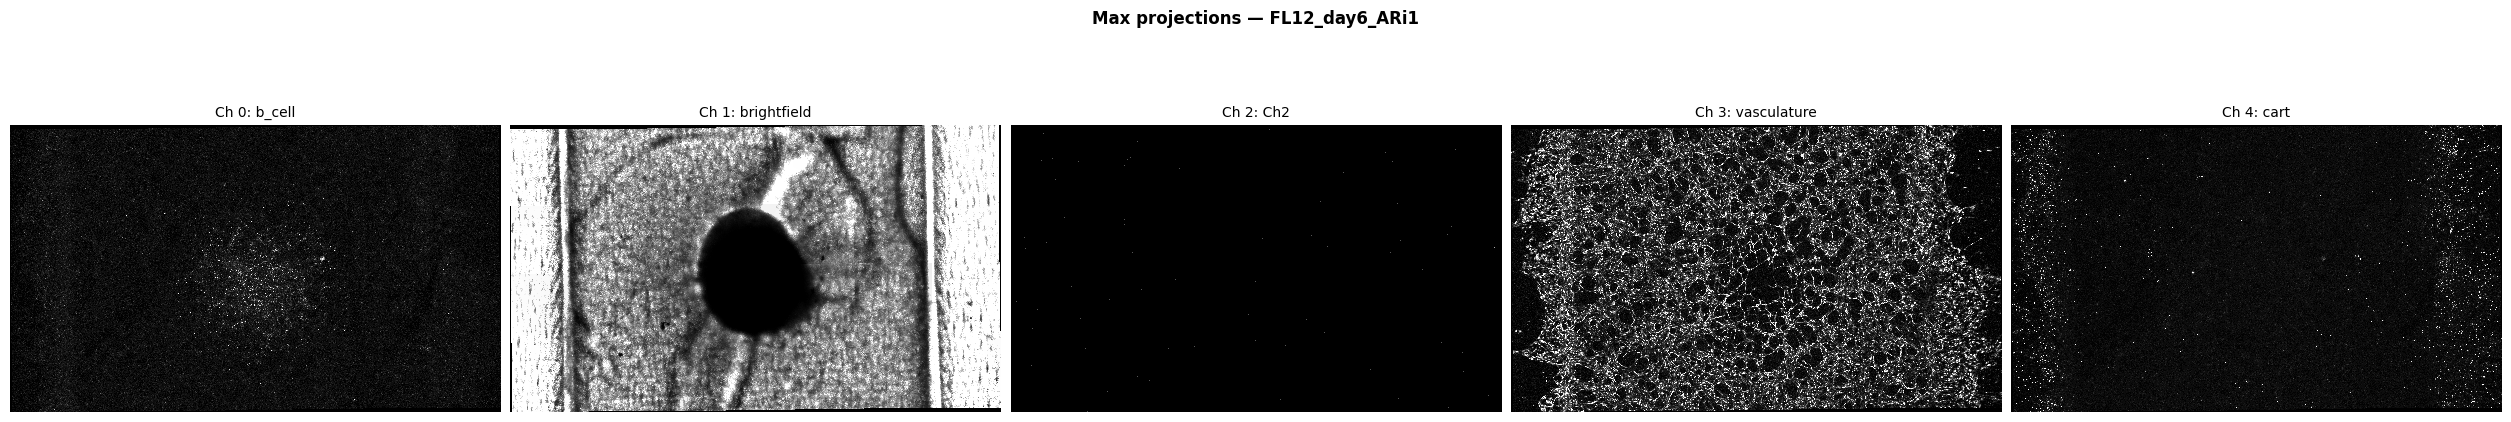

Array shape (C, Y, X): (5, 2780, 4752)
Resolved channel assignments for 5-channel image:
  b_cell         → channel 0
  brightfield    → channel 1
  vasculature    → channel 3
  cart           → channel 4


In [19]:
# ── Sanity-check preview of the first LIF image ──────────────────────────────
# Channel roles are derived per image from its raw channel count via
# `channels_for` (see Functions cell). Edit that helper to change the mapping.
lif_files_preview = sorted(LIF_DIR.glob("*.lif"))
with liffile.LifFile(lif_files_preview[0]) as lif:
    first_image = lif.images[0]
    print(f"LIF file:   {lif_files_preview[0].name}")
    print(f"Image name: {first_image.name}")
    stack = first_image.asarray()
    z_axis = first_image.dims.index('Z')
    max_proj = np.max(stack, axis=z_axis)  # shape: (C, Y, X)
    n_channels = max_proj.shape[0]

channels = channels_for(n_channels)
channel_names = raw_channel_names(n_channels, channels)

fig, axes = plt.subplots(1, n_channels, figsize=(5 * n_channels, 5), constrained_layout=True)
if n_channels == 1:
    axes = [axes]
for ch, ax in enumerate(axes):
    ax.imshow(max_proj[ch], cmap="gray", interpolation="none")
    ax.set_title(f"Ch {ch}: {channel_names[ch]}", fontsize=10)
    ax.axis("off")
fig.suptitle(f"Max projections — {first_image.name}", fontsize=12, fontweight="bold")
plt.show()

print(f"Array shape (C, Y, X): {max_proj.shape}")
print(f"Resolved channel assignments for {n_channels}-channel image:")
for role, raw_index in channels.items():
    print(f"  {role:14s} → channel {raw_index}")

In [20]:
# ── Plotting helper ───────────────────────────────────────────────────────────

def add_condition_label(dataframe):
    """Attach 'condition' (Day{d} {flow} {experiment}) + 'sort_key' columns.

    Requires `add_experiment_info` to have been applied. Returns
    (sorted_dataframe, condition_order) where condition_order is the unique
    list of conditions ordered by day → flow (3mm<7mm) → experiment (ARi<UTD).
    """
    dataframe = dataframe.copy()
    dataframe["condition"] = (
        "Day" + dataframe["day"].astype(str) + " " +
        dataframe["flow"].astype(str) + " " +
        dataframe["experiment"].astype(str)
    )
    dataframe["sort_key"] = (
        dataframe["day"].astype(int) * 100 +
        dataframe["flow"].map({"3mm": 0, "7mm": 1}).fillna(9) * 10 +
        dataframe["experiment"].map({"ARi": 0, "UTD": 1}).fillna(9)
    )
    dataframe = dataframe.sort_values("sort_key")
    condition_order = list(dict.fromkeys(dataframe["condition"]))
    return dataframe, condition_order


## Step 1 — Segment all LIF images

Auto-segments every image in every LIF file in `LIF_DIR` and writes one combined TIF per image to `LABEL_DIR` (channels: 4 raw + 5 labels + embedded metadata).


In [21]:
# Step 1 — segment every image in every LIF file in LIF_DIR → LABEL_DIR
# Channel roles are derived per image inside `segment_and_save` via `channels_for`,
# so a folder containing a mix of 4- and 5-channel LIFs is handled automatically.
lif_files = sorted(LIF_DIR.glob("*.lif"))
print(f"Found {len(lif_files)} LIF files in {LIF_DIR}")

tasks = []
for lif_path in lif_files:
    with liffile.LifFile(lif_path) as lif:
        n_images = len(lif.images)
        print(f"  {lif_path.name}: {n_images} images")
        tasks.extend((lif_path, i) for i in range(n_images))

def _segment_task(lif_path, image_index):
    with liffile.LifFile(lif_path) as lif:
        return segment_and_save(lif.images[image_index], LABEL_DIR, lif_path=lif_path)

with tqdm_joblib(tqdm(desc="Segmenting images", total=len(tasks))) as progress:
    Parallel(n_jobs=NUM_WORKERS, prefer="threads")(
        delayed(_segment_task)(lif_path, image_index)
        for lif_path, image_index in tasks
    )

print(f"\nAll labels saved to: {LABEL_DIR}")

Found 4 LIF files in Z:\Marina\Stellaris\2026.03.10_CART\For analysis
  CART_day6_FL12.lif: 8 images
  CART_day6_FL32.lif: 8 images
  CART_day7_FL12.lif: 8 images
  CART_day7_FL32.lif: 8 images


Segmenting images:   3%|▎         | 1/32 [02:03<1:04:02, 123.95s/it]

  Saved: CART_day6_FL12__FL12_day6_UTD2
  Saved: CART_day6_FL12__FL12_day6_ARi2


Segmenting images:   9%|▉         | 3/32 [02:37<19:15, 39.84s/it]   

  Saved: CART_day6_FL12__FL12_day6_UTD1


...

  Saved: CART_day7_FL32__FL32_UTD3_Merged


Segmenting images:  97%|█████████▋| 31/32 [15:41<00:23, 23.92s/it]

  Saved: CART_day7_FL32__FL32_ARi3_Merged


Segmenting images: 100%|██████████| 32/32 [15:48<00:00, 29.64s/it]

  Saved: CART_day7_FL32__FL32_UTD4_Merged

All labels saved to: Z:\Marina\Stellaris\2026.03.10_CART\For analysis\labels


## Step 2 — Review & edit in napari

Opens one image at a time from `LABEL_DIR`. Use the viewer to correct `chip` and `tumour` masks.

**Shortcuts:** `n` = next · `b` = back · `Ctrl+S` = save · *Reset Label* widget (right panel) wipes a layer for re-drawing.

Edits auto-save when you navigate. Programmatic control: `controls.next()`, `controls.prev()`, `controls.save()`, `controls.goto(i)`, `controls.reset_label("tumour")`.

> When satisfied, copy your best TIFs from `LABEL_DIR` into `CURATED_DIR` before running Step 3.


In [22]:
# Step 2 — open labels in napari for review
viewer, controls = review_in_napari(LABEL_DIR)

Loaded [1/32]: CART_day6_FL12__FL12_day6_ARi1

32 images found. Shortcuts: n=next, b=back, Ctrl+S=save
Labels auto-save when you navigate to the next/prev image.


In [23]:
# Optional — napari navigation helpers (run as needed)
# controls.next()
# controls.prev()
# controls.goto(9)
controls.save()


  Saved: CART_day6_FL12__FL12_day6_ARi1.tif


## Step 3 — Analyse curated labels

Reads combined TIFs from `CURATED_DIR`, computes cell counts, tumour-distance distributions, and B↔CART colocalisation per region. Writes three CSVs + per-image QC PNGs to `OUTPUT_DIR`.


In [27]:
# Step 3 — run analysis on curated labels
all_results, all_distances, colocalisation_dataframe = analyse_from_labels(
    LABEL_DIR, OUTPUT_DIR,
    gauss_sigmas_um=[5, 10, 20, 50, 100],
    proximity_radii_um=[5, 10, 20, 30, 40, 50, 100],
    num_workers=NUM_WORKERS,
)

# Attach patient / day / flow / fixation / experiment columns in-place
for dataframe in (all_results, all_distances, colocalisation_dataframe):
    add_experiment_info(dataframe)

print(f"all_results:              {len(all_results)} rows")
print(f"all_distances:            {len(all_distances)} rows")
print(f"colocalisation_dataframe: {len(colocalisation_dataframe)} rows")

Analysing corrected labels: 100%|██████████| 32/32 [08:07<00:00, 15.23s/it]


all_results:              576 rows
all_distances:            899519 rows
colocalisation_dataframe: 4864 rows


## Plots

CART scatter, fixed-vs-live bars, and normalised enrichment. All figures are written to `OUTPUT_DIR`.


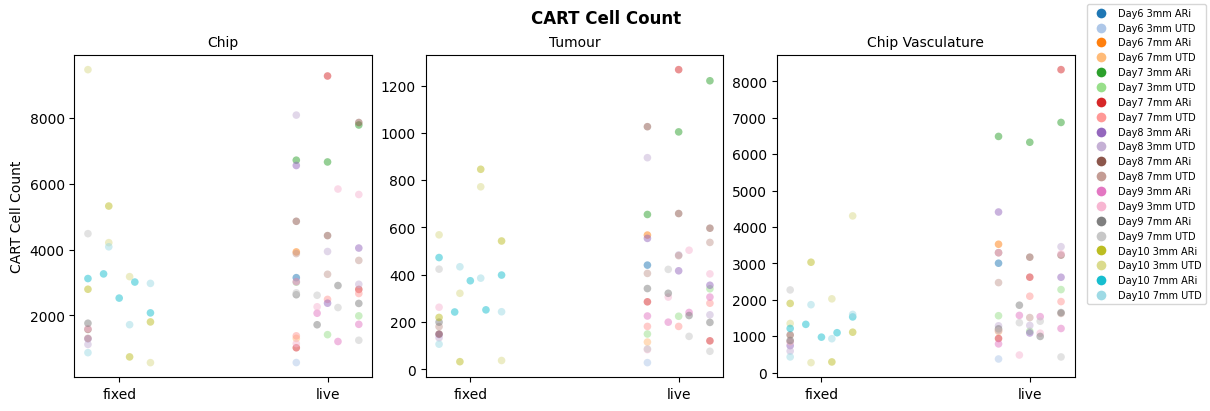

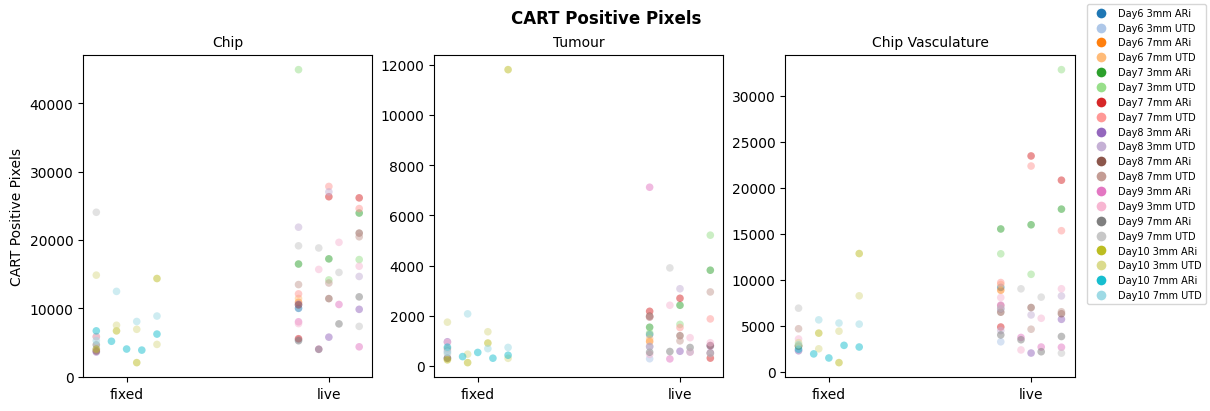

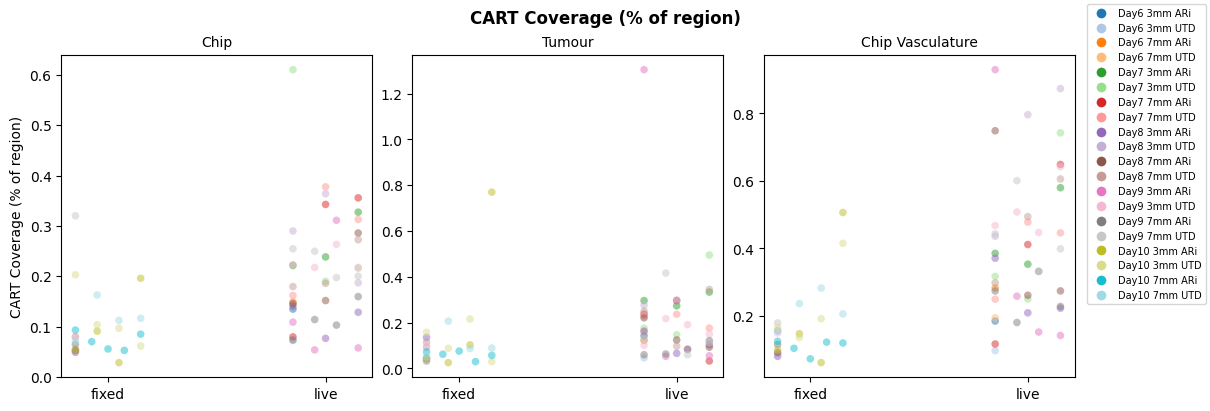

In [ ]:
# ── Scatter: CART cells per fixation, coloured by condition ──────────────────
cart_data = all_results[
    (all_results["cell_type"] == "CART cells") &
    (all_results["region"].isin(["chip", "tumour", "chip_vasculature"])) &
    (all_results["day"] != "unknown")
]
cart_data, condition_order = add_condition_label(cart_data)

fixation_categories = ["fixed", "live"]
plot_regions = ["chip", "tumour", "chip_vasculature"]
metrics = [("cell_count", "CART Cell Count"),
           ("positive_pixels", "CART Positive Pixels"),
           ("positive_pixel_pct", "CART Coverage (% of region)")]

condition_colors = {cond: plt.cm.tab20(i / max(len(condition_order) - 1, 1))
                    for i, cond in enumerate(condition_order)}

for metric, ylabel in metrics:
    fig, axes = plt.subplots(1, len(plot_regions), figsize=(12, 4),
                             sharey=False, constrained_layout=True)
    fig.suptitle(ylabel, fontsize=12, fontweight="bold")

    for ax, region in zip(axes, plot_regions):
        region_data = cart_data[cart_data["region"] == region]
        for fixation_index, fixation in enumerate(fixation_categories):
            fixation_data = region_data[region_data["fixation"] == fixation]
            for condition in condition_order:
                values = fixation_data.loc[fixation_data["condition"] == condition, metric].values
                jitter = np.linspace(-0.15, 0.15, max(len(values), 1))
                for jitter_offset, value in zip(jitter, values):
                    ax.scatter(fixation_index + jitter_offset, value,
                               color=condition_colors[condition], s=30, alpha=0.5,
                               edgecolor="None", linewidth=0.4, zorder=3)
        ax.set_xticks(range(len(fixation_categories)))
        ax.set_xticklabels(fixation_categories, fontsize=10)
        ax.set_title(region.replace("_", " ").title(), fontsize=10)
        ax.set_ylabel(ylabel if ax is axes[0] else "")

    legend_handles = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=condition_colors[c], markersize=8, label=c)
        for c in condition_order
    ]
    fig.legend(handles=legend_handles, loc="outside right upper", fontsize=7, ncol=1)
    fig.savefig(OUTPUT_DIR / f"CART_{metric}_by_condition.png", dpi=150, bbox_inches="tight")
    plt.show()


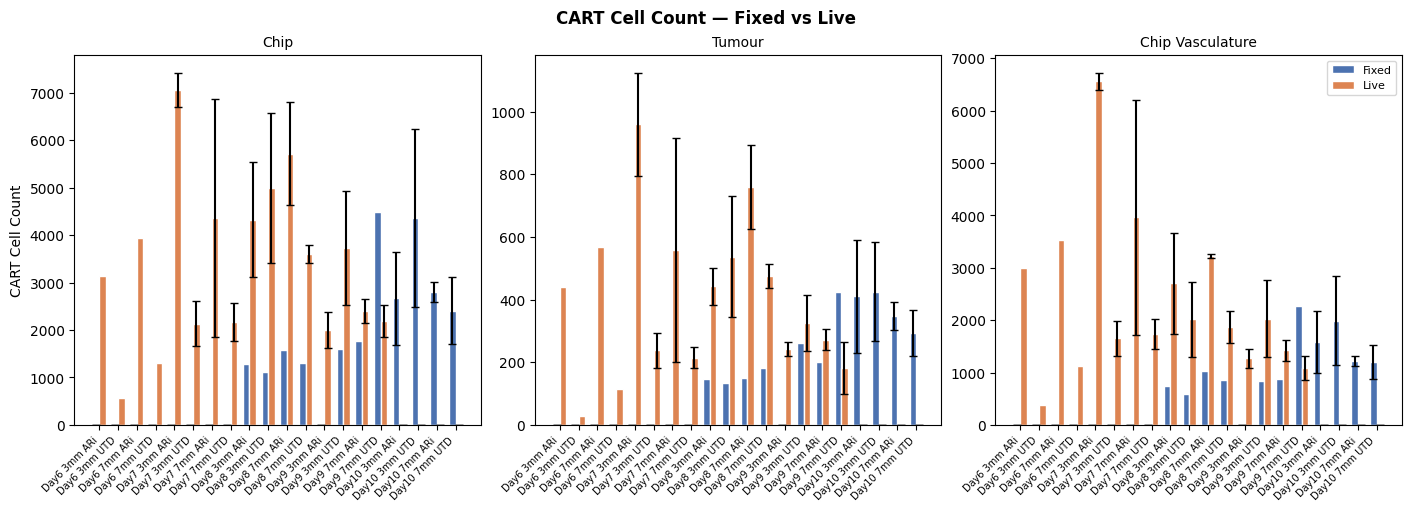

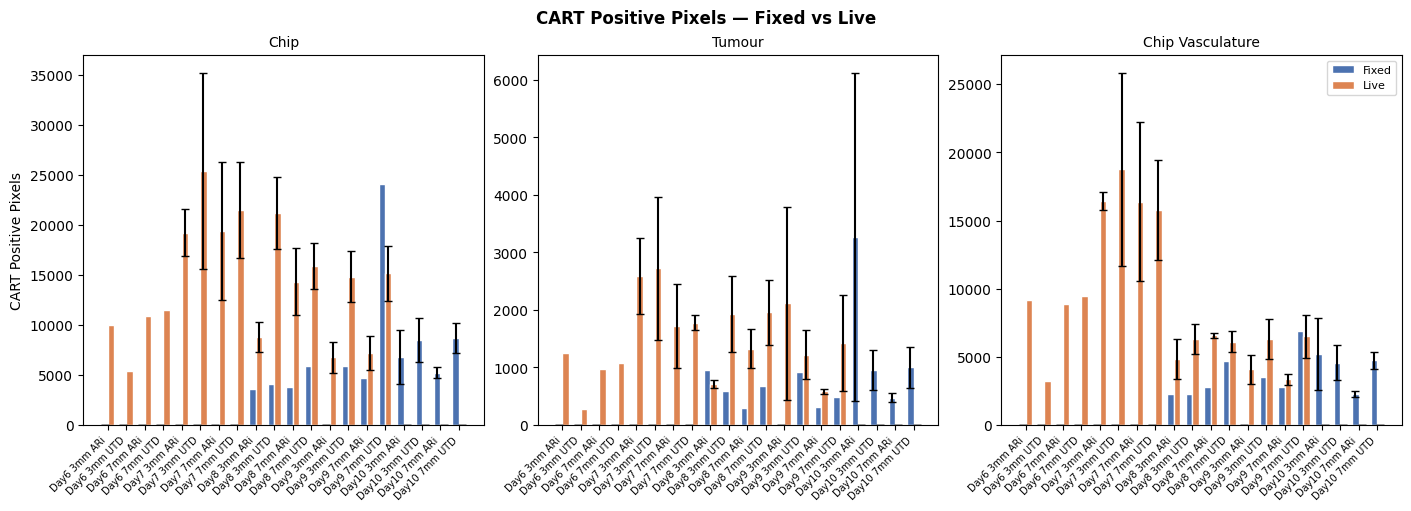

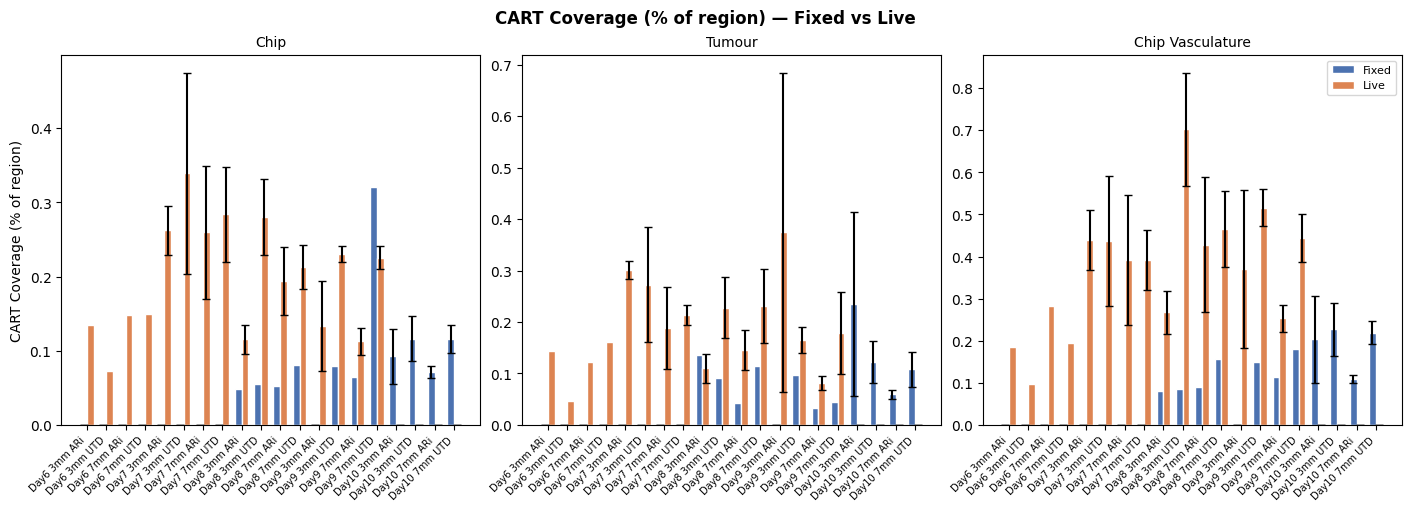

In [ ]:
# ── Bar: Fixed vs Live per condition ─────────────────────────────────────────
cart_bar = all_results[
    (all_results["cell_type"] == "CART cells") &
    (all_results["region"].isin(["chip", "tumour", "chip_vasculature"])) &
    (all_results["day"] != "unknown")
]
cart_bar, condition_order_bar = add_condition_label(cart_bar)

fixation_categories = ["fixed", "live"]
plot_regions = ["chip", "tumour", "chip_vasculature"]
metrics = [("cell_count", "CART Cell Count"),
           ("positive_pixels", "CART Positive Pixels"),
           ("positive_pixel_pct", "CART Coverage (% of region)")]

bar_width = 0.35
fixation_colors = {"fixed": "#4C72B0", "live": "#DD8452"}

for metric, ylabel in metrics:
    fig, axes = plt.subplots(1, len(plot_regions), figsize=(14, 5),
                             sharey=False, constrained_layout=True)
    fig.suptitle(f"{ylabel} — Fixed vs Live", fontsize=12, fontweight="bold")

    for ax, region in zip(axes, plot_regions):
        region_data = cart_bar[cart_bar["region"] == region]
        grouped = region_data.groupby(["condition", "fixation"])[metric]
        means = grouped.mean().unstack(fill_value=0)
        sems = grouped.sem().unstack(fill_value=0)
        for fix in fixation_categories:
            if fix not in means.columns:
                means[fix] = 0.0
                sems[fix] = 0.0
        means = means.reindex([c for c in condition_order_bar if c in means.index])
        sems = sems.reindex(means.index)

        x = np.arange(len(means))
        ax.bar(x - bar_width / 2, means["fixed"], bar_width,
               yerr=sems["fixed"], capsize=3, color=fixation_colors["fixed"],
               edgecolor="white", label="Fixed")
        ax.bar(x + bar_width / 2, means["live"], bar_width,
               yerr=sems["live"], capsize=3, color=fixation_colors["live"],
               edgecolor="white", label="Live")
        ax.set_xticks(x)
        ax.set_xticklabels(means.index, fontsize=7, rotation=45, ha="right")
        ax.set_title(region.replace("_", " ").title(), fontsize=10)
        ax.set_ylabel(ylabel if ax is axes[0] else "")

    axes[-1].legend(fontsize=8)
    fig.savefig(OUTPUT_DIR / f"CART_{metric}_fixed_vs_live.png", dpi=150, bbox_inches="tight")
    plt.show()


                       image               region  positive_pixels  cart_px_chip  region_area_px  area_chip  cart_enrichment
  Day6_Plate2_ARi_3mm_Merged               tumour             1245         10018          872268    7422132         0.014605
  Day6_Plate2_ARi_3mm_Merged     chip_vasculature             9174         10018         4972514    7422132         0.613515
  Day6_Plate2_ARi_3mm_Merged chip_not_vasculature              844         10018         2449618    7422132         0.027806
  Day6_Plate2_ARi_7mm_Merged               tumour              968         10891          792198    7369240         0.009555
  Day6_Plate2_ARi_7mm_Merged     chip_vasculature             8859         10891         3137063    7369240         0.346272
  Day6_Plate2_ARi_7mm_Merged chip_not_vasculature             2032         10891         4232177    7369240         0.107151
  Day6_Plate2_UTD_3mm_Merged               tumour              278          5409          608249    7454461         0.004194


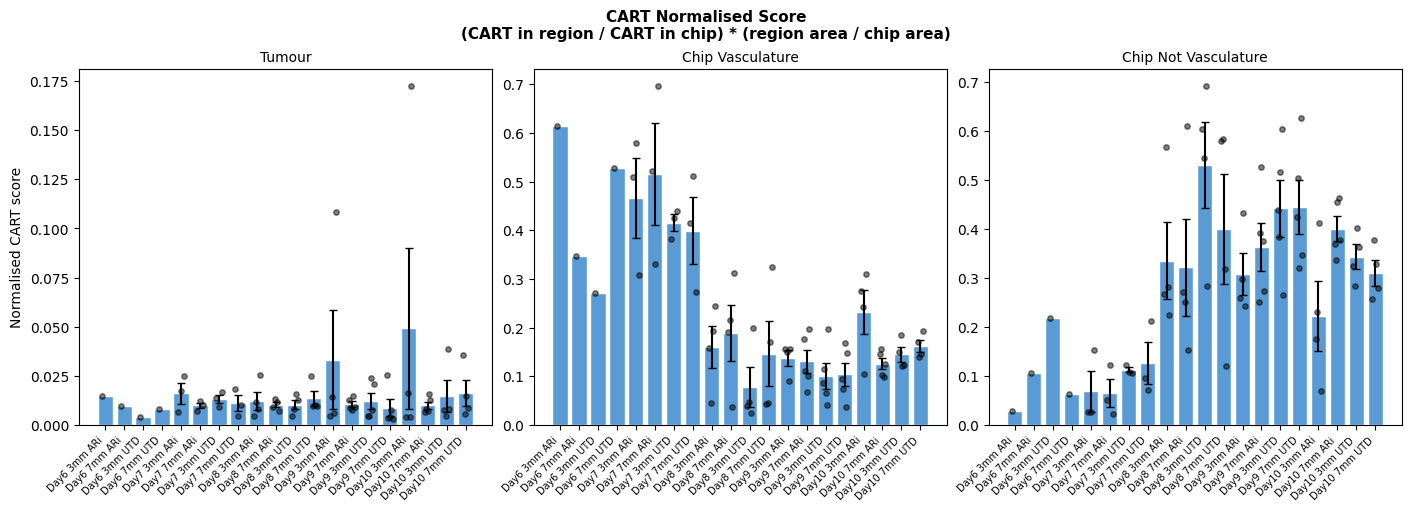

In [ ]:
# ── Normalised CART enrichment per region ────────────────────────────────────
# Formula: (CART_px_in_region / CART_px_in_chip) * (region_area / chip_area)
enrichment_regions = ["tumour", "chip_vasculature", "chip_not_vasculature"]

cart_all = all_results[all_results["cell_type"] == "CART cells"].copy()
chip_rows = cart_all[cart_all["region"] == "chip"][
    ["image", "positive_pixels", "region_area_px"]
].rename(columns={"positive_pixels": "cart_px_chip", "region_area_px": "area_chip"})

enrichment = cart_all[cart_all["region"].isin(enrichment_regions)].merge(
    chip_rows, on="image", how="left")
enrichment["cart_enrichment"] = (
    (enrichment["positive_pixels"] / enrichment["cart_px_chip"].replace(0, np.nan)) *
    (enrichment["region_area_px"]  / enrichment["area_chip"].replace(0, np.nan))
)
enrichment, _ = add_condition_label(enrichment)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(enrichment_regions), figsize=(14, 5),
                         sharey=False, constrained_layout=True)
fig.suptitle("CART Normalised Score\n(CART in region / CART in chip) * (region area / chip area)",
             fontsize=11, fontweight="bold")

for ax, region in zip(axes, enrichment_regions):
    region_data = enrichment[enrichment["region"] == region]
    conditions = list(dict.fromkeys(region_data["condition"]))
    x_positions = np.arange(len(conditions))
    means = [region_data.loc[region_data["condition"] == c, "cart_enrichment"].mean() for c in conditions]
    sems  = [region_data.loc[region_data["condition"] == c, "cart_enrichment"].sem()  for c in conditions]
    ax.bar(x_positions, means, yerr=sems, capsize=3, color="#5A9BD5", edgecolor="white")
    for xi, c in enumerate(conditions):
        vals = region_data.loc[region_data["condition"] == c, "cart_enrichment"].values
        jitter = np.linspace(-0.15, 0.15, max(len(vals), 1))
        for j, v in zip(jitter, vals):
            ax.scatter(xi + j, v, color="black", s=15, alpha=0.5, zorder=5)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(conditions, fontsize=7, rotation=45, ha="right")
    ax.set_title(region.replace("_", " ").title(), fontsize=10)
    ax.set_ylabel("Normalised CART score" if ax is axes[0] else "")

fig.savefig(OUTPUT_DIR / "CART_normalised_enrichment.png", dpi=150, bbox_inches="tight")
plt.show()

enrichment.to_csv(OUTPUT_DIR / "enrichment_quantities.csv", index=False)
print(f"Saved enrichment CSV → {OUTPUT_DIR / 'enrichment_quantities.csv'}")
